**Análisis de la demanda de ususarios del Metro de Panamá: Patrones de uso y proyecciones para la optimización del servicio**

Marianela Durán
8-860-947

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import seaborn as sns
import itertools
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path_linea1 = "/content/drive/MyDrive/TFM Maestria/Documentos/datos/demanda-de-usuarios-2024-linea-1.csv"

Mounted at /content/drive


In [3]:
df_linea1 = pd.read_csv(path_linea1, encoding='ISO-8859-1', sep=';', skiprows=4)

# **Limpieza de Datos y Primera Vista del Dataset**

In [4]:
#Inspección inicial
print("Información General")
print("")
print(df_linea1.info())

Información General

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Mes        85 non-null     object
 1   Laborable  85 non-null     object
 2   S bados    85 non-null     object
 3   Feriados   85 non-null     object
dtypes: object(4)
memory usage: 2.8+ KB
None


In [5]:
#Primera vista de primeras filas del df
print("Encabezado df Línea 1")
print("")
display(df_linea1.head())
print("")

Encabezado df Línea 1



,Mes,Laborable,S bados,Feriados
0,ene-18,"251,595","194,234","82,150"
1,feb-18,"260,374","169,070","83,443"
2,mar-18,"277,487","222,283","91,326"
3,abr-18,"279,776","217,594","95,591"
4,may-18,"274,325","197,867","92,049"


In [6]:
#Vista de la cola del df
print("Cola df Línea 1")
display(df_linea1.tail(5))

Cola df Línea 1


,Mes,Laborable,S bados,Feriados
80,sep-24,"278,669","203,721","96,446"
81,oct-24,"287,138","193,088","94,907"
82,nov-24,"286,616","205,954","100,663"
83,dic-24,"286,347","222,379","123,259"
84,ene-24,"253,289","178,482","83,709"


In [7]:
#Quito espacios y normalizo encabezados
df_linea1.columns = df_linea1.columns.str.replace(' ', '')
df_linea1.columns = df_linea1.columns.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

In [8]:
#Convierto encabezados a todo minúsculas
df_linea1.columns = df_linea1.columns.str.lower()

#Verifico cambios
print(df_linea1.columns)

Index(['mes', 'laborable', 's bados', 'feriados'], dtype='object')


In [9]:
#Corrijo nomenclaturas de encabezados
df_linea1 = df_linea1.rename(columns= {
    "laborable" : "laborables",
    "s bados" : "sabados"
})

#Verifico cambios
print(df_linea1.columns)

Index(['mes', 'laborables', 'sabados', 'feriados'], dtype='object')


In [10]:
#Verifico tipos de datos
print(df_linea1.dtypes)

mes           object
laborables    object
sabados       object
feriados      object
dtype: object


In [11]:
df_linea1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   mes         85 non-null     object
 1   laborables  85 non-null     object
 2   sabados     85 non-null     object
 3   feriados    85 non-null     object
dtypes: object(4)
memory usage: 2.8+ KB


In [12]:
#Convierto a string por si acaso
for col in ['laborables', 'sabados', 'feriados']:
  df_linea1[col] = df_linea1[col].astype(str)

#Elimino separadores de miles en puntos o comas
for col in ['laborables', 'sabados', 'feriados']:
  df_linea1[col] = df_linea1[col].str.replace(r'[,.]', '', regex=True)

#Convierto a numeros enteros, formato int64
for col in ['laborables', 'sabados', 'feriados']:
  df_linea1[col] = df_linea1[col].astype(int)

#Verifico cambios
print("\nVariables numéricas convertidas a Integer:")
print(df_linea1.dtypes)


Variables numéricas convertidas a Integer:
mes           object
laborables     int64
sabados        int64
feriados       int64
dtype: object


**Tratamiento de variable mes a formato datetime**

In [13]:
#verifico nomenclaturas para identificar posibles inconcistencias
print(df_linea1['mes'].unique())

['ene-18' 'feb-18' 'mar-18' 'abr-18' 'may-18' 'jun-18' 'jul-18' 'ago-18'
 'sep-18' 'oct-18' 'nov-18' 'dic-18' 'ene-19' 'feb-19' 'mar-19' 'abr-19'
 'may-19' 'jun-19' 'jul-19' 'ago-19' 'sep-19' 'oct-19' 'nov-19' 'dic-19'
 'ene-20' 'feb-20' 'mar-20' 'abr-20' 'may-20' 'jun-20' 'jul-20' 'ago-20'
 'sep-20' 'oct-20' 'nov-20' 'dic-20' 'ene-21' 'feb-21' 'mar-21' 'abr-21'
 'may-21' 'jun-21' 'jul-21' 'ago-21' 'sep-21' 'oct-21' 'nov-21' 'dic-21'
 'ene-22' 'feb-22' 'mar-22' 'abr-22' 'may-22' 'jun-22' 'jul-22' 'ago-22'
 'sep-22' 'oct-22' 'nov-22' 'dic-22' 'ene-23' 'feb-23' 'mar-23' 'abr-23'
 'may-23' 'jun-23' 'jul-23' 'ago-23' 'sep-23' 'oct-23' 'nov-23' 'dic-23'
 'ene-24' 'feb-24' 'mar-24' 'abr-24' 'may-24' 'jun-24' 'jul-24' 'ago-24'
 'sep-24' 'oct-24' 'nov-24' 'dic-24']


In [14]:
#Creo diccionario para traducir nomenclatura de meses de español a inglés
meses_esp_ing = {
    'ene' : 'jan', 'feb' : 'feb', 'mar' : 'mar', 'abr' : 'apr',
    'may' : 'may', 'jun' : 'jun', 'jul' : 'jul', 'ago' : 'aug',
    'sep' : 'sep', 'oct' : 'oct', 'nov' : 'nov', 'dic' : 'dec'
}

#Creo funcion para hacer la traducción
def traducir_mes(mes):
  mes_str = str(mes)
  mes_abreviado = mes_str[:3]
  return meses_esp_ing.get(mes_abreviado, mes_str) + mes_str[3:]

#Aplico la traducción a la columna mes
df_linea1['mes'] = df_linea1['mes'].apply(traducir_mes)

In [15]:
#Convierto a formato datetime
df_linea1['mes'] = pd.to_datetime(df_linea1['mes'], format = '%b-%y').dt.to_period('M')

In [16]:
#Verifico formatos de las variables una vez terminados los cambios
print(df_linea1.dtypes)

mes           period[M]
laborables        int64
sabados           int64
feriados          int64
dtype: object


In [17]:
#Convierto "mes" de period[M] a timestamp
df_linea1["mes"] = df_linea1["mes"].dt.to_timestamp()

#Creo variable año a partir de la variable mes y convierto a integer
df_linea1["año"] = df_linea1["mes"].dt.year.astype("int64")

#Verifico los cambios
print(df_linea1.dtypes)
print(df_linea1.head())


mes           datetime64[ns]
laborables             int64
sabados                int64
feriados               int64
año                    int64
dtype: object
         mes  laborables  sabados  feriados   año
0 2018-01-01      251595   194234     82150  2018
1 2018-02-01      260374   169070     83443  2018
2 2018-03-01      277487   222283     91326  2018
3 2018-04-01      279776   217594     95591  2018
4 2018-05-01      274325   197867     92049  2018


In [18]:
display(df_linea1.head())

,mes,laborables,sabados,feriados,año
0,2018-01-01,251595,194234,82150,2018
1,2018-02-01,260374,169070,83443,2018
2,2018-03-01,277487,222283,91326,2018
3,2018-04-01,279776,217594,95591,2018
4,2018-05-01,274325,197867,92049,2018


**Busco nulos en variable mes**

In [19]:
print(df_linea1["mes"].value_counts())

mes
2024-01-01    2
2018-01-01    1
2018-03-01    1
2018-02-01    1
2018-05-01    1
             ..
2024-08-01    1
2024-09-01    1
2024-10-01    1
2024-11-01    1
2024-12-01    1
Name: count, Length: 84, dtype: int64


In [20]:
#hay dos fechas asignadas a 2024-01-01. Elimino la  que corresponde a enero 2025
df_linea1 = df_linea1[~((df_linea1["mes"] == "2024-01-01") &
                        (df_linea1.duplicated(subset=["mes"], keep="first")))]

In [21]:
#Reviso Cambios
print(df_linea1["mes"].value_counts())
print("")
#Reviso nuevamente duplicados en variable mes
print("Duplicados en variable mes de df línea1:")
print(df_linea1["mes"].duplicated().sum())

mes
2018-01-01    1
2018-02-01    1
2018-03-01    1
2018-04-01    1
2018-05-01    1
             ..
2024-08-01    1
2024-09-01    1
2024-10-01    1
2024-11-01    1
2024-12-01    1
Name: count, Length: 84, dtype: int64

Duplicados en variable mes de df línea1:
0


**Busco nulos en variables laborables, sabados y feriados**

In [22]:
#Verifico valores nulos en todo el df
print(df_linea1.isnull().sum())

mes           0
laborables    0
sabados       0
feriados      0
año           0
dtype: int64


In [23]:
#Busco nulos en cada variable numérica de demandas
print("\nNulos en variable Laborables:", (df_linea1['laborables'] == 0).sum())
print("\nNulos en variable Sabados:", (df_linea1['sabados'] == 0).sum())
print("\nNulos en variable Feriados:", (df_linea1['feriados'] == 0).sum())


Nulos en variable Laborables: 0

Nulos en variable Sabados: 2

Nulos en variable Feriados: 5


In [24]:
#Identifico a qué periodo corresponden estos nulos
sabados_cero = df_linea1[df_linea1['sabados'] == 0][['mes', 'sabados']]
print("Mes y año de nulos en variable sabados:")
print(sabados_cero)
print("")
feriados_cero = df_linea1[df_linea1['feriados'] == 0][['mes', 'feriados']]
print("Mes y año de nulos en variable feriados:")
print(feriados_cero)

Mes y año de nulos en variable sabados:
          mes  sabados
36 2021-01-01        0
37 2021-02-01        0

Mes y año de nulos en variable feriados:
          mes  feriados
29 2020-06-01         0
30 2020-07-01         0
31 2020-08-01         0
32 2020-09-01         0
36 2021-01-01         0


**Busco duplicados**

In [25]:
#Busco duplicados
print("Duplicados en df línea1:")
print(df_linea1.duplicated().sum())

Duplicados en df línea1:
0


In [26]:
#Verifico nuevamente la información del df
print(df_linea1.info())

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   mes         84 non-null     datetime64[ns]
 1   laborables  84 non-null     int64         
 2   sabados     84 non-null     int64         
 3   feriados    84 non-null     int64         
 4   año         84 non-null     int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 3.9 KB
None


# **EDA**

## 1. Análisis General de Tendencias Temporales

Medidas de tendencia central (2018-2024)

In [27]:
display(df_linea1.describe())


,mes,laborables,sabados,feriados,año
count,84,84.000000,84.000000,84.000000,84.000000
mean,2021-06-16 07:25:42.857142784,235198.190476,173556.250000,83266.309524,2021.000000
min,2018-01-01 00:00:00,28378.000000,0.000000,0.000000,2018.000000
25%,2019-09-23 12:00:00,182260.750000,141942.000000,72211.750000,2019.000000
50%,2021-06-16 00:00:00,259352.500000,187282.500000,90186.000000,2021.000000
75%,2023-03-08 18:00:00,280825.750000,205558.750000,97558.250000,2023.000000
max,2024-12-01 00:00:00,364789.000000,289491.000000,151369.000000,2024.000000
std,NaN,72540.722467,63490.468423,32152.866701,2.012012


Visualizaciones generales de tendencias temporales

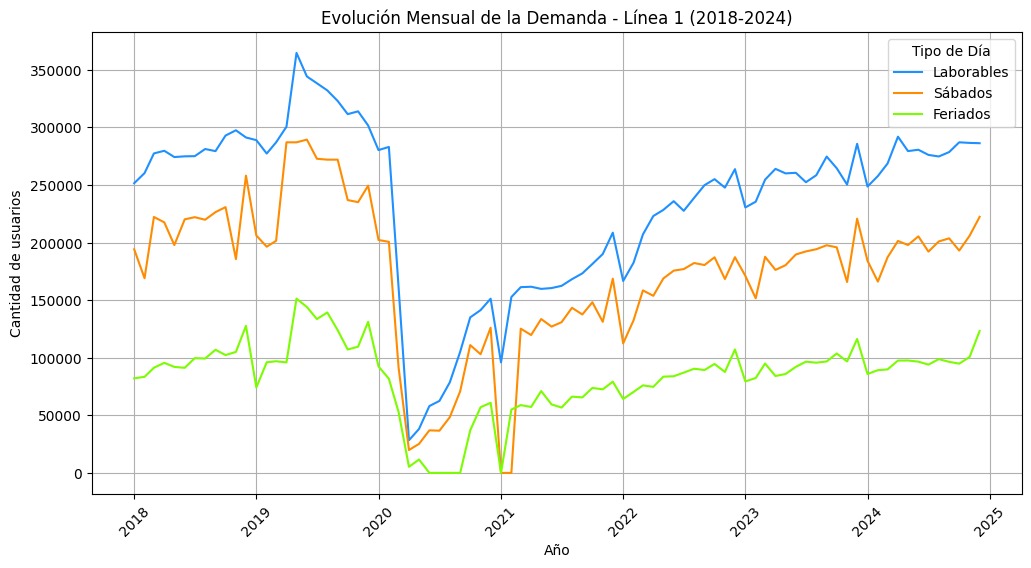

In [28]:
#Gráfico de líneas de la evolución mensual de la demanda
plt.figure(figsize=(12,6))

sns.lineplot(data=df_linea1, x="mes", y="laborables", label="Laborables", color="dodgerblue")
sns.lineplot(data=df_linea1, x="mes", y="sabados", label="Sábados", color="darkorange")
sns.lineplot(data=df_linea1, x="mes", y="feriados", label="Feriados", color="lawngreen")

plt.title("Evolución Mensual de la Demanda - Línea 1 (2018-2024)")
plt.xlabel("Año")
plt.ylabel("Cantidad de usuarios")
plt.legend(title="Tipo de Día")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


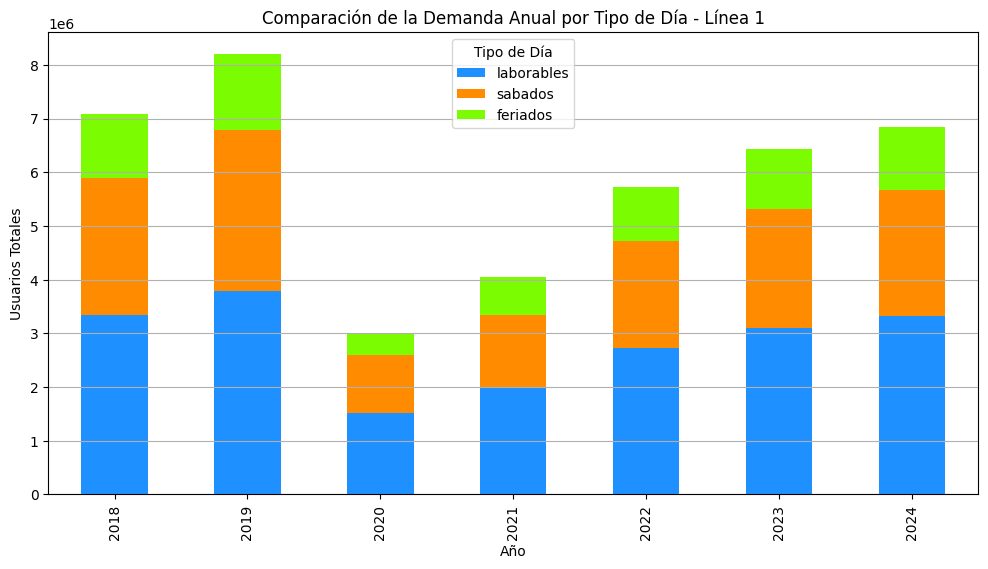

In [29]:
#Demanda total anual por tipo de día
df_anual = df_linea1.groupby("año")[["laborables", "sabados", "feriados"]].sum()

colores = ["dodgerblue","darkorange","lawngreen"]
df_anual.plot(kind="bar", stacked=True, figsize=(12, 6), color=colores)

plt.title("Comparación de la Demanda Anual por Tipo de Día - Línea 1")
plt.xlabel("Año")
plt.ylabel("Usuarios Totales")
plt.legend(title="Tipo de Día")
plt.grid(axis="y")
plt.show()


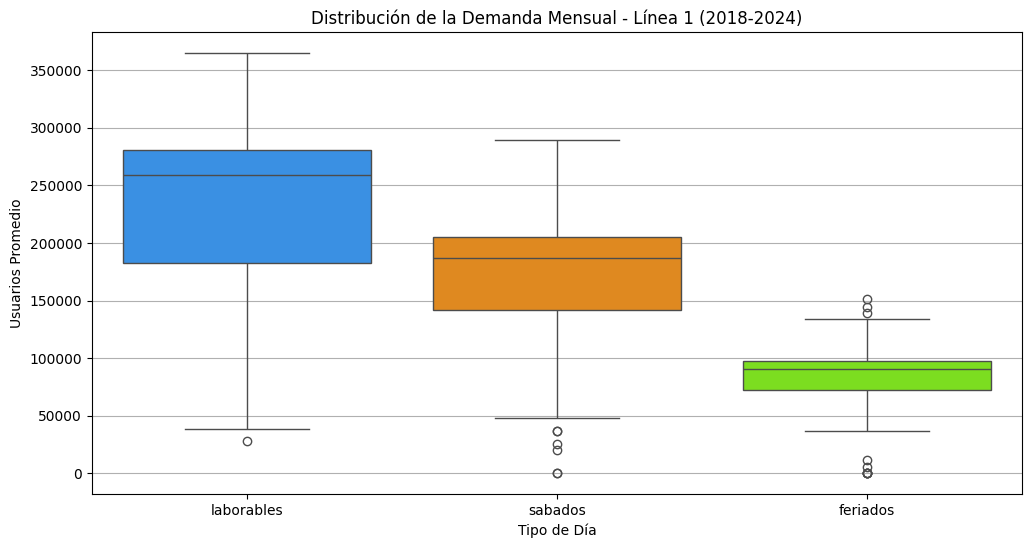

In [30]:
#Boxplot de la demanda mensual
plt.figure(figsize=(12,6))

sns.boxplot(data=df_linea1.melt(id_vars=["mes"], value_vars=["laborables", "sabados", "feriados"]),
            x="variable", y="value", palette=colores)

plt.title("Distribución de la Demanda Mensual - Línea 1 (2018-2024)")
plt.xlabel("Tipo de Día")
plt.ylabel("Usuarios Promedio")
plt.grid(axis="y")
plt.show()


## 2. Evaluación del Impacto de la Pandemia COVID-19 (2020-2021)

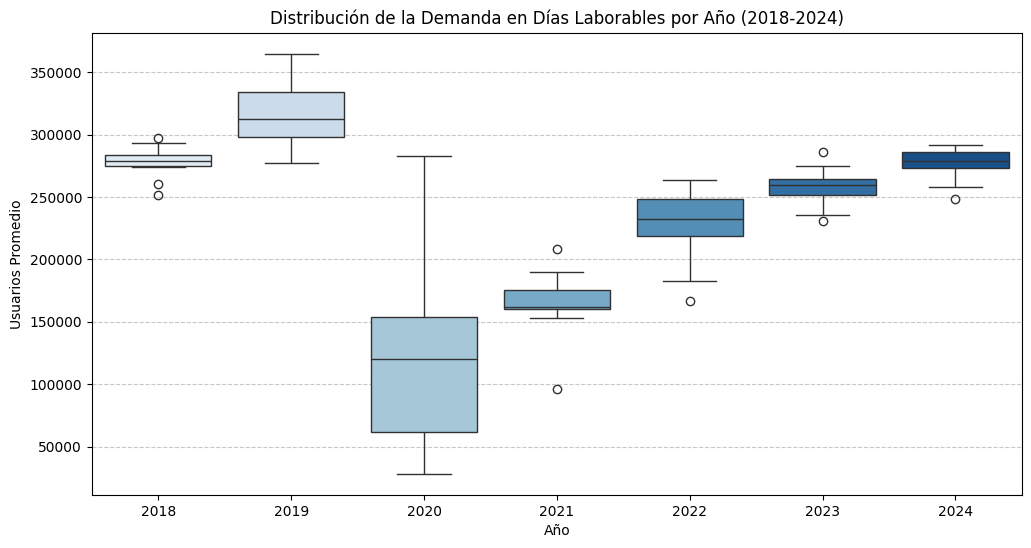

In [31]:
#Boxplot Comparativo (2018-2024) - Identificación de valores atípicos en 2020-2021
plt.figure(figsize=(12,6))
sns.boxplot(x='año', y='laborables', data=df_linea1, palette='Blues')
plt.title("Distribución de la Demanda en Días Laborables por Año (2018-2024)")
plt.xlabel("Año")
plt.ylabel("Usuarios Promedio")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

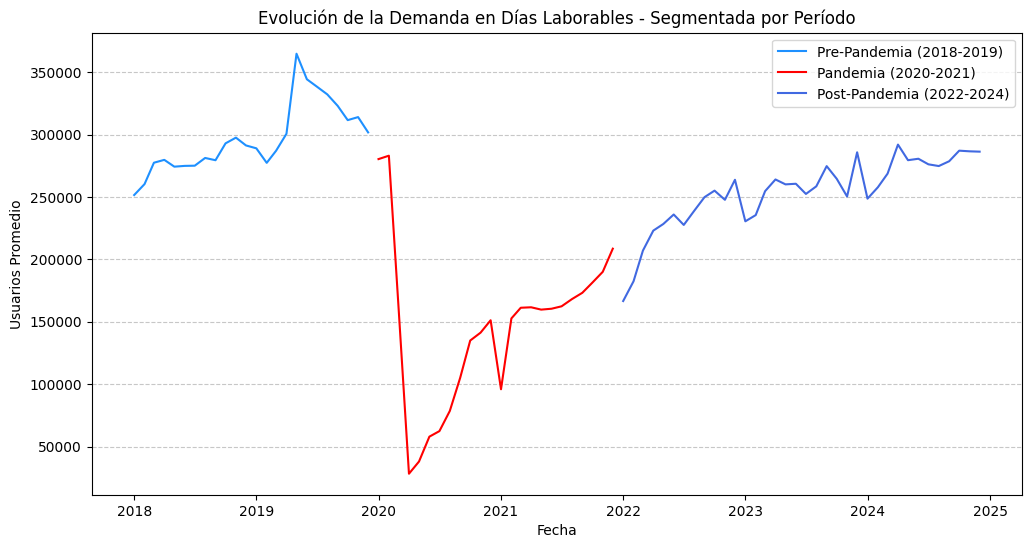

In [32]:
#Evolución de la Demanda Segmentada (Pre-Pandemia, Pandemia, Post-Pandemia)
plt.figure(figsize=(12,6))
sns.lineplot(x='mes', y='laborables', data=df_linea1[df_linea1['año'] < 2020], label="Pre-Pandemia (2018-2019)", color="dodgerblue")
sns.lineplot(x='mes', y='laborables', data=df_linea1[(df_linea1['año'] >= 2020) & (df_linea1['año'] <= 2021)], label="Pandemia (2020-2021)", color="red")
sns.lineplot(x='mes', y='laborables', data=df_linea1[df_linea1['año'] > 2021], label="Post-Pandemia (2022-2024)", color="royalblue")
plt.title("Evolución de la Demanda en Días Laborables - Segmentada por Período")
plt.xlabel("Fecha")
plt.ylabel("Usuarios Promedio")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [33]:
#Análisis de Variabilidad (Coeficiente de Variación - CV)
df_cv = df_linea1.groupby("año")[["laborables", "sabados", "feriados"]].agg(["mean", "std"])
df_cv["CV_laborables"] = (df_cv[("laborables", "std")] / df_cv[("laborables", "mean")]) * 100
df_cv["CV_sabados"] = (df_cv[("sabados", "std")] / df_cv[("sabados", "mean")]) * 100
df_cv["CV_feriados"] = (df_cv[("feriados", "std")] / df_cv[("feriados", "mean")]) * 100

In [34]:
print(df_cv.describe)

<bound method NDFrame.describe of          laborables                      sabados                     feriados  \
               mean           std           mean           std           mean   
año                                                                             
2018  278024.083333  12938.402434  213709.166667  23514.433397   98074.666667   
2019  315357.583333  26127.854932  250541.250000  34812.363052  116965.000000   
2020  126932.500000  84886.794823   89384.500000  62990.342344   33238.416667   
2021  164697.916667  26742.489812  113813.333333  54667.108940   59660.000000   
2022  227247.500000  29156.987672  165393.583333  22955.337294   84104.416667   
2023  257690.583333  15090.449951  185314.916667  17837.976875   93745.500000   
2024  276437.166667  12679.133056  196737.000000  13896.070753   97076.166667   

                   CV_laborables CV_sabados CV_feriados  
               std                                       
año                                    

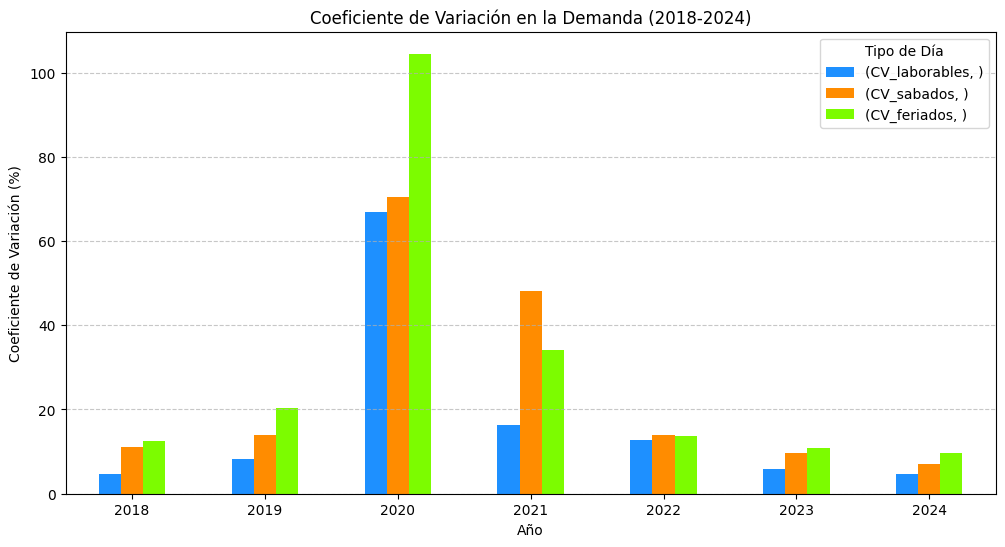

In [35]:
#grafica de comparación de Coeficiente de Variación
df_cv[["CV_laborables", "CV_sabados", "CV_feriados"]].plot(kind="bar", figsize=(12,6), color=colores)
plt.title("Coeficiente de Variación en la Demanda (2018-2024)")
plt.xlabel("Año")
plt.ylabel("Coeficiente de Variación (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Tipo de Día")
plt.show()


In [36]:
#Creo variables dummy para los años 2020 y 2021
df_linea1["dummy_pandemia"] = df_linea1["año"].apply(lambda x: 1 if x in [2020, 2021] else 0)

#Verifico la columna creada
df_linea1[["año", "dummy_pandemia"]].drop_duplicates().sort_values(by="año")


,año,dummy_pandemia
0,2018,0
12,2019,0
24,2020,1
36,2021,1
48,2022,0
60,2023,0
72,2024,0


## 3. Análisis de Estacionalidad

3.1 EVALUACIÓN VISUAL DE ESTACIONALIDAD

In [37]:
#Filtro los datos excluyendo 2020 y 2021
df_estacionalidad = df_linea1[~df_linea1["año"].isin([2020, 2021])].copy()

#Agrego columna numérica del mes para análisis mensual
df_estacionalidad["mes_num"] = df_estacionalidad["mes"].dt.month

In [38]:
print(df_estacionalidad.columns)
print(df_estacionalidad.dtypes)

Index(['mes', 'laborables', 'sabados', 'feriados', 'año', 'dummy_pandemia',
       'mes_num'],
      dtype='object')
mes               datetime64[ns]
laborables                 int64
sabados                    int64
feriados                   int64
año                        int64
dummy_pandemia             int64
mes_num                    int32
dtype: object


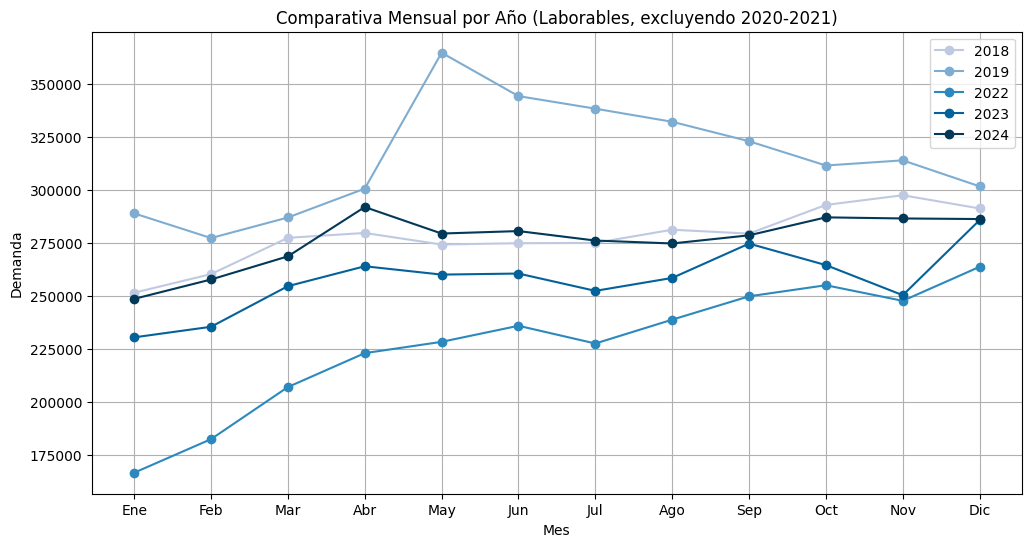

In [39]:
plt.figure(figsize=(12,6))

#Defino el colormap azul para dias laborables
colors = cm.PuBu(np.linspace(0.3, 1, len(df_estacionalidad["año"].unique())))

#grafica de líneas de patrones mensual-anual excluyendo pandemia
for color, year in zip(colors, sorted(df_estacionalidad["año"].unique())):
    datos_anio = df_estacionalidad[df_estacionalidad["año"] == year]
    plt.plot(datos_anio["mes_num"], datos_anio["laborables"],
             marker="o", label=str(year), color=color)

plt.title("Comparativa Mensual por Año (Laborables, excluyendo 2020-2021)")
plt.xlabel("Mes")
plt.ylabel("Demanda")
plt.xticks(range(1,13), ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
plt.grid(True)
plt.legend()
plt.show()

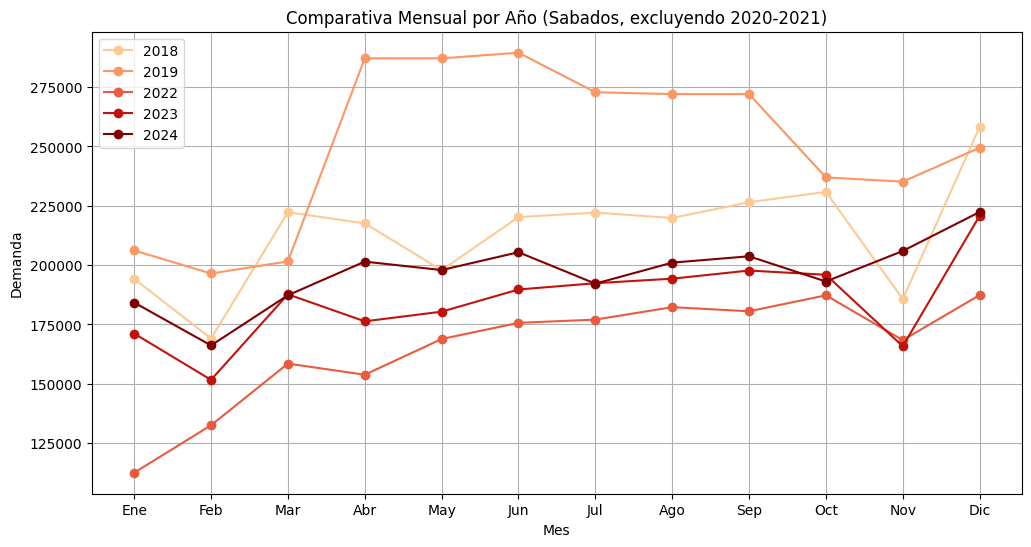

In [40]:
plt.figure(figsize=(12,6))

#defino el colormap naranja para dias sabados
colors = cm.OrRd(np.linspace(0.3, 1, len(df_estacionalidad["año"].unique())))

#grafica de líneas de patrones mensual-anual excluyendo pandemia
for color, year in zip(colors, sorted(df_estacionalidad["año"].unique())):
    datos_anio = df_estacionalidad[df_estacionalidad["año"] == year]
    plt.plot(datos_anio["mes_num"], datos_anio["sabados"],
             marker="o", label=str(year), color=color)

plt.title("Comparativa Mensual por Año (Sabados, excluyendo 2020-2021)")
plt.xlabel("Mes")
plt.ylabel("Demanda")
plt.xticks(range(1,13), ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
plt.grid(True)
plt.legend()
plt.show()

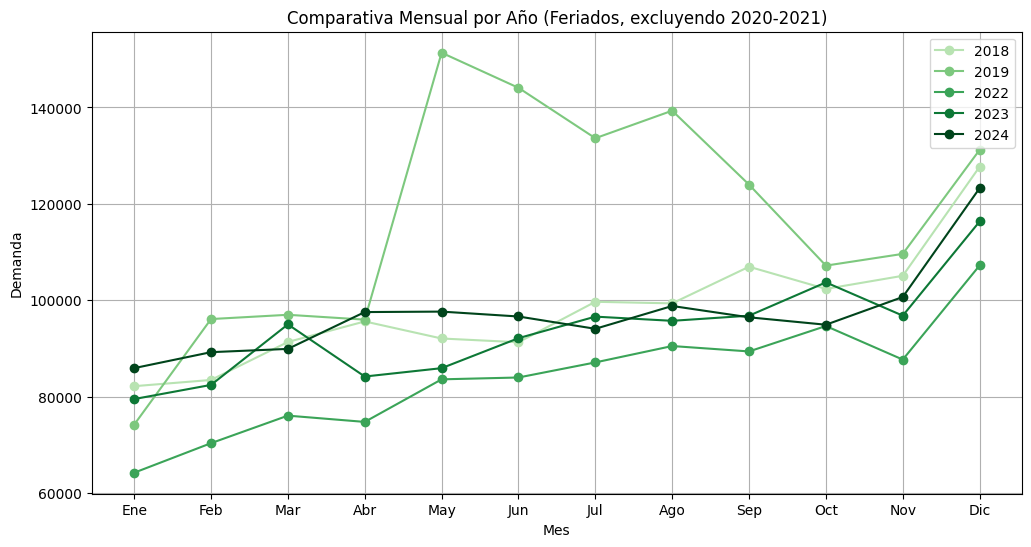

In [41]:
plt.figure(figsize=(12,6))

#defino el colormap verde para dias feriados
colors = cm.Greens(np.linspace(0.3, 1, len(df_estacionalidad["año"].unique())))

#grafico de lineas de praton mensual-anual excluyendo pandemia
for color, year in zip(colors, sorted(df_estacionalidad["año"].unique())):
    datos_anio = df_estacionalidad[df_estacionalidad["año"] == year]
    plt.plot(datos_anio["mes_num"], datos_anio["feriados"],
             marker="o", label=str(year), color=color)

plt.title("Comparativa Mensual por Año (Feriados, excluyendo 2020-2021)")
plt.xlabel("Mes")
plt.ylabel("Demanda")
plt.xticks(range(1,13), ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
plt.grid(True)
plt.legend()
plt.show()

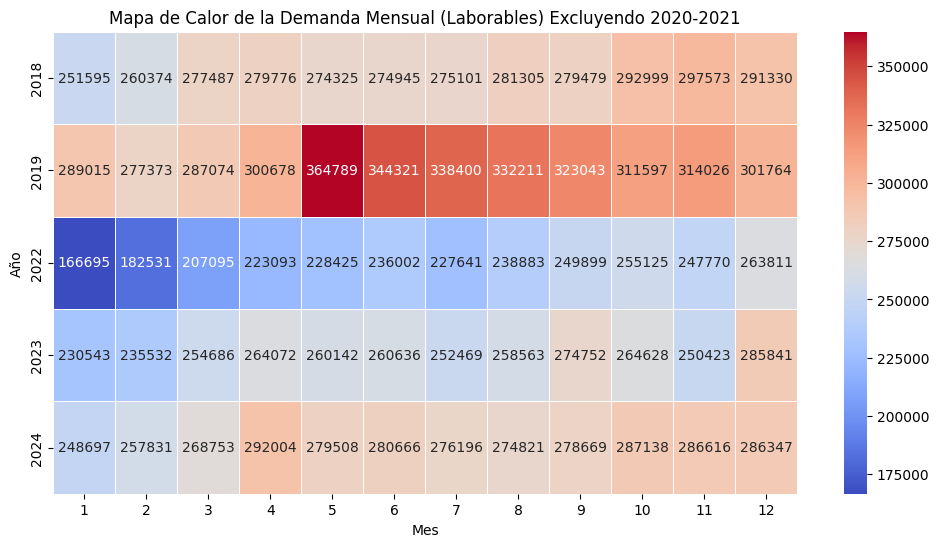

In [42]:
#heatmap de la Demanda Mensual (sin 2020-2021)
df_pivot = df_estacionalidad.pivot_table(index="año", columns=df_estacionalidad["mes"].dt.month, values="laborables", aggfunc="mean")

plt.figure(figsize=(12, 6))
sns.heatmap(df_pivot, cmap="coolwarm", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Mapa de Calor de la Demanda Mensual (Laborables) Excluyendo 2020-2021")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

3.2 ANÁLISIS DE ESTACIONALIDAD CON VALORES ESTADÍSTICOS

In [43]:
#Me aseguro que la variable mes funcione como índice y que esté en formato datetime
df_estacionalidad = df_estacionalidad.set_index("mes")

In [44]:
#Aplico descomposición estacional
descomposicion = seasonal_decompose(df_estacionalidad["laborables"], model="additive", period=12)

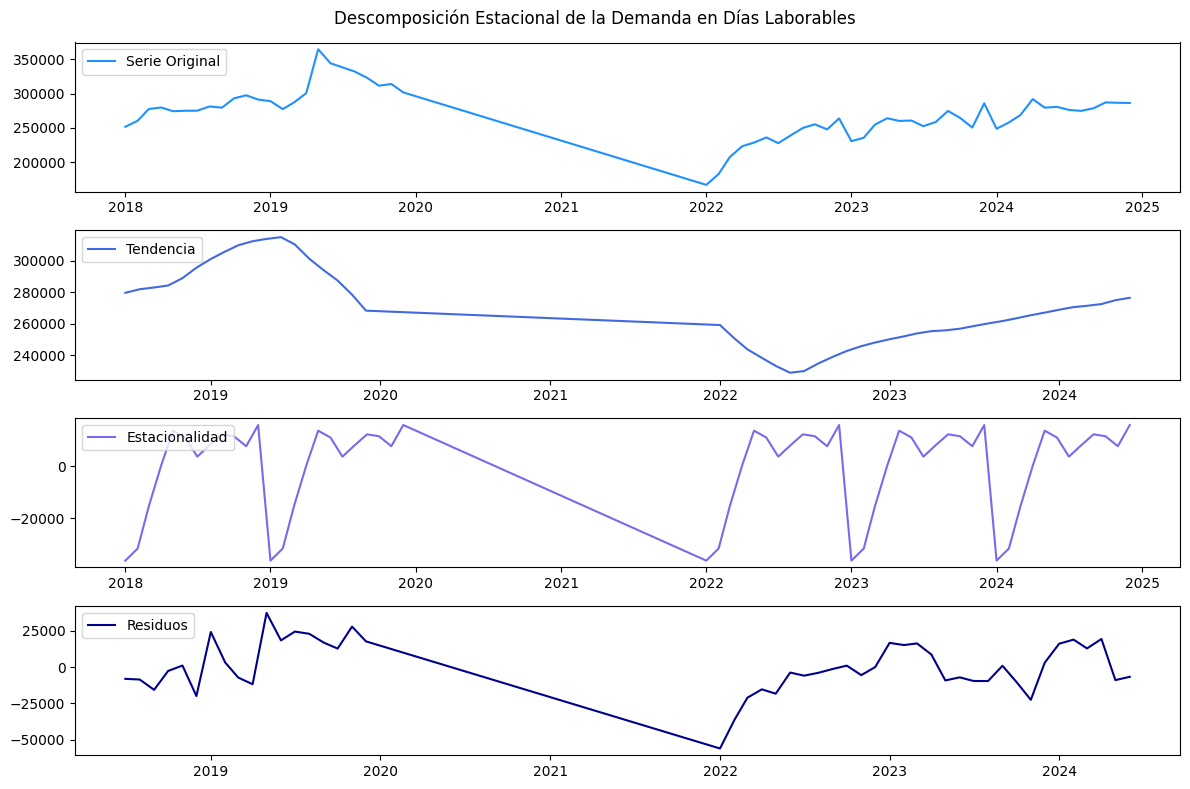

In [45]:
#Visualizo resultados
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(df_estacionalidad["laborables"], label="Serie Original", color='dodgerblue')
plt.legend(loc="upper left")

plt.subplot(4, 1, 2)
plt.plot(descomposicion.trend, label="Tendencia", color="royalblue")
plt.legend(loc="upper left")

plt.subplot(4, 1, 3)
plt.plot(descomposicion.seasonal, label="Estacionalidad", color="mediumslateblue")
plt.legend(loc="upper left")

plt.subplot(4, 1, 4)
plt.plot(descomposicion.resid, label="Residuos", color="darkblue")
plt.legend(loc="upper left")

plt.suptitle("Descomposición Estacional de la Demanda en Días Laborables")
plt.tight_layout()
plt.show()

In [46]:
#calculo de promedio y desviación estándar por tipo de día
stats_dias = df_estacionalidad[['laborables', 'sabados', 'feriados']].agg(['mean', 'std'])

#agrego tambien coeficiente de variación (CV)
stats_dias.loc["CV (%)"] = (stats_dias.loc["std"] / stats_dias.loc["mean"]) * 100

#imprimo resultados
display(stats_dias.round(2))


,laborables,sabados,feriados
mean,270951.38,202339.18,97993.15
std,35085.93,36938.02,17590.86
CV (%),12.95,18.26,17.95


## 4. Análisis de Volatilidad

In [47]:
#calculo de estadísticas de variabilidad
variabilidad_stats = df_linea1.groupby("año")[["laborables", "sabados", "feriados"]].agg(["mean", "std", "median", "min", "max"])
variabilidad_stats.columns = ["_".join(col).strip() for col in variabilidad_stats.columns]
display(variabilidad_stats)

,laborables_mean,laborables_std,laborables_median,laborables_min,laborables_max,sabados_mean,sabados_std,sabados_median,sabados_min,sabados_max,feriados_mean,feriados_std,feriados_median,feriados_min,feriados_max
año,,,,,,,,,,,,,,,
2018,278024.083333,12938.402434,278483.0,251595,297573,213709.166667,23514.433397,220050.5,169070,258191,98074.666667,12171.725173,97465.5,82150,127701
2019,315357.583333,26127.854932,312811.5,277373,364789,250541.250000,34812.363052,260770.5,196466,289491,116965.000000,23755.467623,116801.5,74167,151369
2020,126932.500000,84886.794823,120127.5,28378,283113,89384.500000,62990.342344,81193.5,19875,202290,33238.416667,34720.764915,24293.0,0,92473
2021,164697.916667,26742.489812,162084.0,96034,208637,113813.333333,54667.108940,131064.5,0,168707,59660.000000,20349.005180,62523.5,0,79236
2022,227247.500000,29156.987672,232213.5,166695,263811,165393.583333,22955.337294,172261.5,112515,187355,84104.416667,11578.674084,85519.0,64187,107211
2023,257690.583333,15090.449951,259352.5,230543,285841,185314.916667,17837.976875,188707.5,151652,220791,93745.500000,10133.725488,95347.5,79479,116336
2024,276437.166667,12679.133056,279088.5,248697,292004,196737.000000,13896.070753,199472.5,166153,222379,97076.166667,9316.134458,96531.0,85900,123259


In [48]:
#creo df de volatilidad temporal - y guardo diferenciaciones mensuales
df_volatilidad = df_linea1[["laborables", "sabados", "feriados"]].copy()

#aplico la diferenciaciaon mensual
df_volatilidad["laborables_diff"] = df_volatilidad["laborables"].diff()
df_volatilidad["sabados_diff"] = df_volatilidad["sabados"].diff()
df_volatilidad["feriados_diff"] = df_volatilidad["feriados"].diff()

In [49]:
df_volatilidad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, 0 to 83
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   laborables       84 non-null     int64  
 1   sabados          84 non-null     int64  
 2   feriados         84 non-null     int64  
 3   laborables_diff  83 non-null     float64
 4   sabados_diff     83 non-null     float64
 5   feriados_diff    83 non-null     float64
dtypes: float64(3), int64(3)
memory usage: 4.6 KB


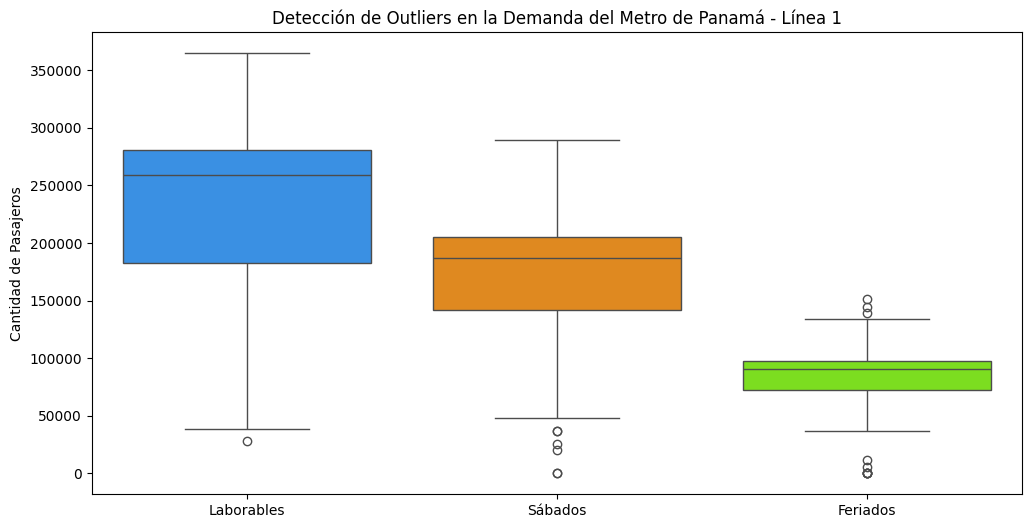

In [50]:
#grafica boxplot de detección de outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_volatilidad[["laborables", "sabados", "feriados"]], orient="v", palette=colores)
plt.title("Detección de Outliers en la Demanda del Metro de Panamá - Línea 1")
plt.ylabel("Cantidad de Pasajeros")
plt.xticks(ticks=[0, 1, 2], labels=["Laborables", "Sábados", "Feriados"])
plt.show()

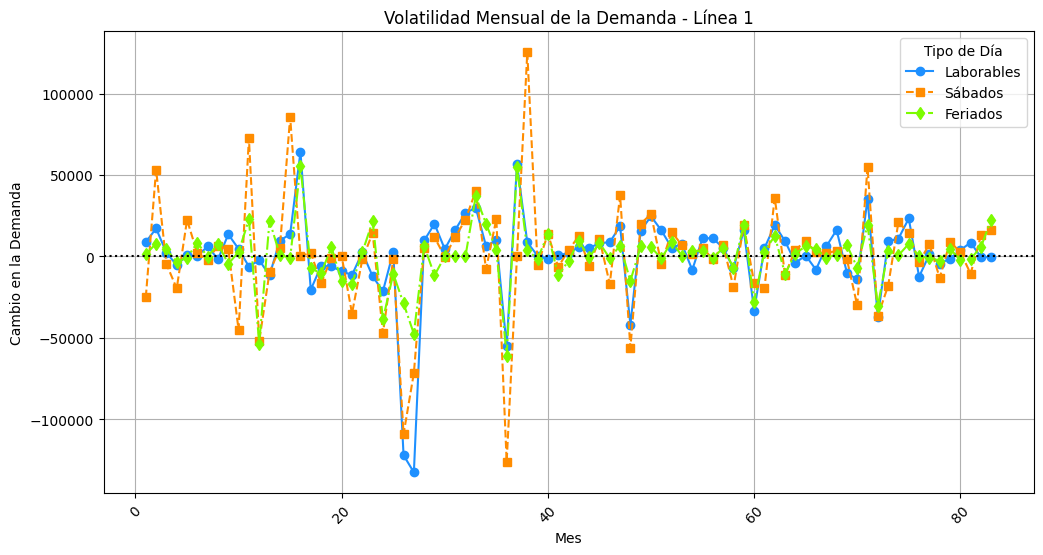

In [51]:
#grafica de lineas de picos y caidas de demanda
plt.figure(figsize=(12, 6))
plt.plot(df_volatilidad.index, df_volatilidad["laborables_diff"], label="Laborables", marker='o', color='dodgerblue', linestyle="-")
plt.plot(df_volatilidad.index, df_volatilidad["sabados_diff"], label="Sábados", marker='s', color='darkorange', linestyle="--")
plt.plot(df_volatilidad.index, df_volatilidad["feriados_diff"], label="Feriados", marker='d', color='lawngreen', linestyle="-.")
plt.axhline(y=0, color="black", linestyle="dotted")
plt.legend(title="Tipo de Día")
plt.title("Volatilidad Mensual de la Demanda - Línea 1")
plt.xlabel("Mes")
plt.ylabel("Cambio en la Demanda")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## 5. Correlaciones entre Variables

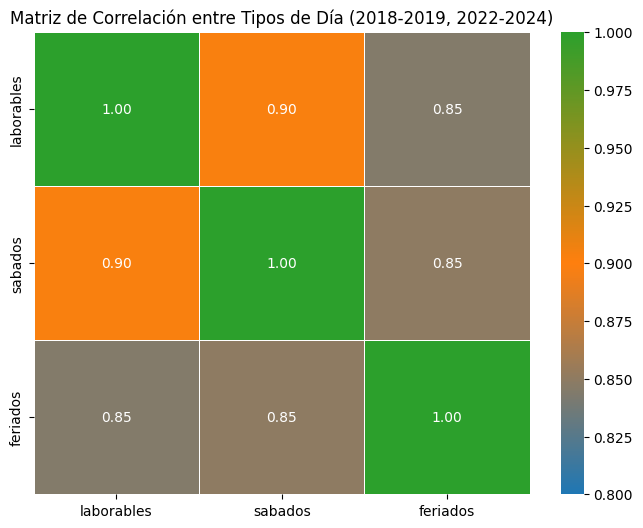

In [52]:
#filtro el df excluyendo los años de la pandemia
df_corr = df_linea1[~df_linea1["año"].isin([2020, 2021])]

#calculo la matriz de correlación general
correlation_matrix = df_corr[["laborables", "sabados", "feriados"]].corr()

#creo una paleta de colores personalizada
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
custom_cmap = LinearSegmentedColormap.from_list("metro_cmap", colors)

#heatmap de la matriz de correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap=custom_cmap, fmt=".2f", linewidths=0.5, vmin=0.8, vmax=1)
plt.title("Matriz de Correlación entre Tipos de Día (2018-2019, 2022-2024)")
plt.show()


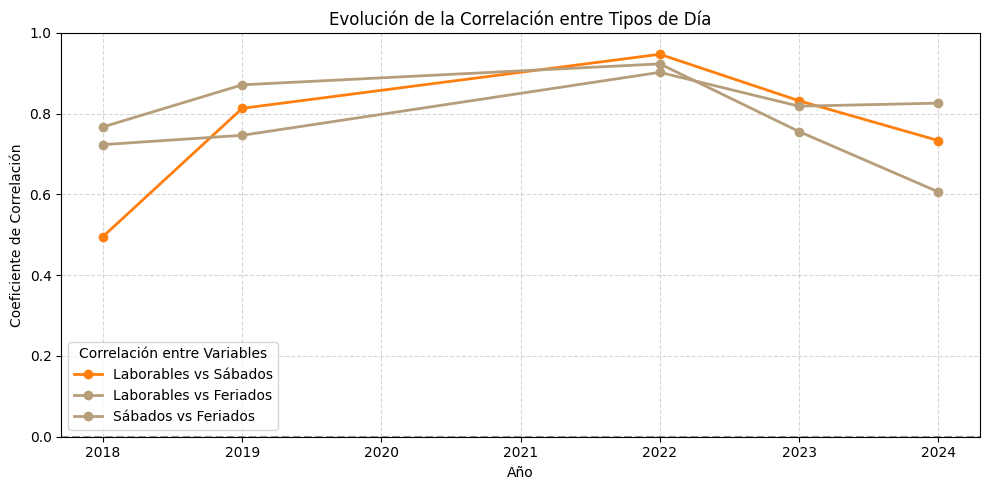

In [53]:
#cálculo de correlaciones por año (excluyendo 2020-2021)
correlation_by_year = df_corr.groupby("año")[["laborables", "sabados", "feriados"]].corr().unstack()

plt.figure(figsize=(10, 5))

#correlación entre dias laborables vs sábados
plt.plot(correlation_by_year.index, correlation_by_year[("laborables", "sabados")],
         marker="o", color="#ff7f0e", label="Laborables vs Sábados", linewidth=2)

#correlación entre laborables vs feriados
plt.plot(correlation_by_year.index, correlation_by_year[("laborables", "feriados")],
         marker="o", color="#b69e7a", label="Laborables vs Feriados", linewidth=2)

#correlación entre sábados vs feriados
plt.plot(correlation_by_year.index, correlation_by_year[("sabados", "feriados")],
         marker="o", color="#b69e7a", label="Sábados vs Feriados", linewidth=2)

#armo el grafico
plt.axhline(y=0, color="grey", linestyle="--", alpha=0.8)
plt.legend(title="Correlación entre Variables")
plt.xlabel("Año")
plt.ylabel("Coeficiente de Correlación")
plt.title("Evolución de la Correlación entre Tipos de Día")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


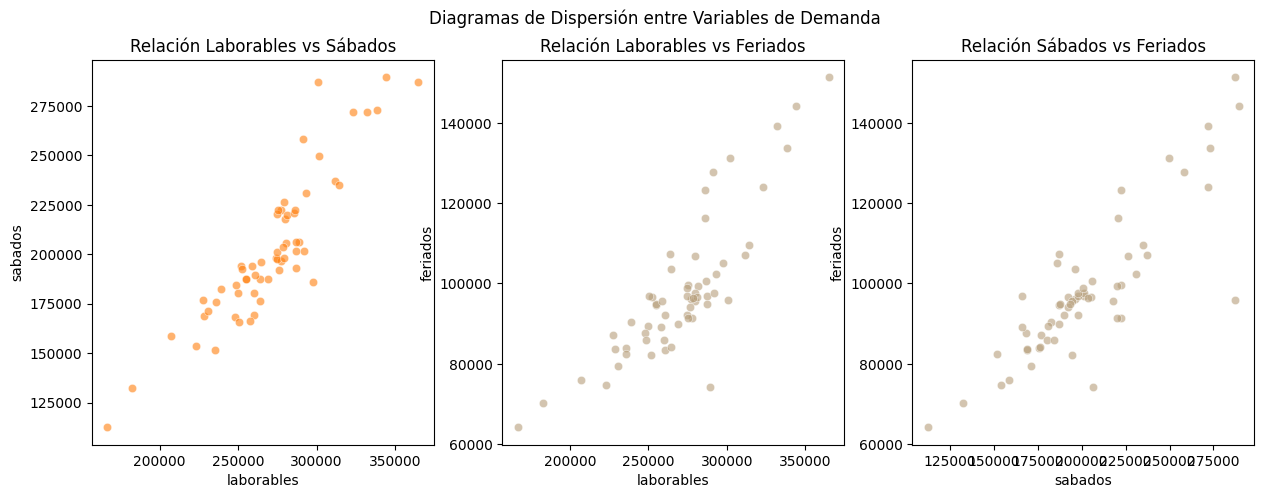

In [54]:
#grafica de dispersión entre Variables
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df_corr, x="laborables", y="sabados", color="#ff7f0e", alpha=0.6)
plt.title("Relación Laborables vs Sábados")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df_corr, x="laborables", y="feriados", color="#b69e7a", alpha=0.6)
plt.title("Relación Laborables vs Feriados")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df_corr, x="sabados", y="feriados", color="#b69e7a", alpha=0.6)
plt.title("Relación Sábados vs Feriados")

plt.suptitle("Diagramas de Dispersión entre Variables de Demanda")
plt.show()

## 6. Visualizaciones antes del modelo

In [55]:
#Prueba de Estacionariedad con ADF para confirmar si la serie del conjunto original es o no estacionria
adf_test = adfuller(df_linea1["laborables"])
adf_result = {
    "Estadístico ADF": adf_test[0],
    "Valor P": adf_test[1],
    "Conclusión": "La serie es estacionaria" if adf_test[1] < 0.05 else "La serie no es estacionaria"
}
print("Prueba de Dickey-Fuller Aumentada (ADF)")
print(adf_result)

Prueba de Dickey-Fuller Aumentada (ADF)
{'Estadístico ADF': np.float64(-1.9449781459444815), 'Valor P': np.float64(0.31120657636724314), 'Conclusión': 'La serie no es estacionaria'}


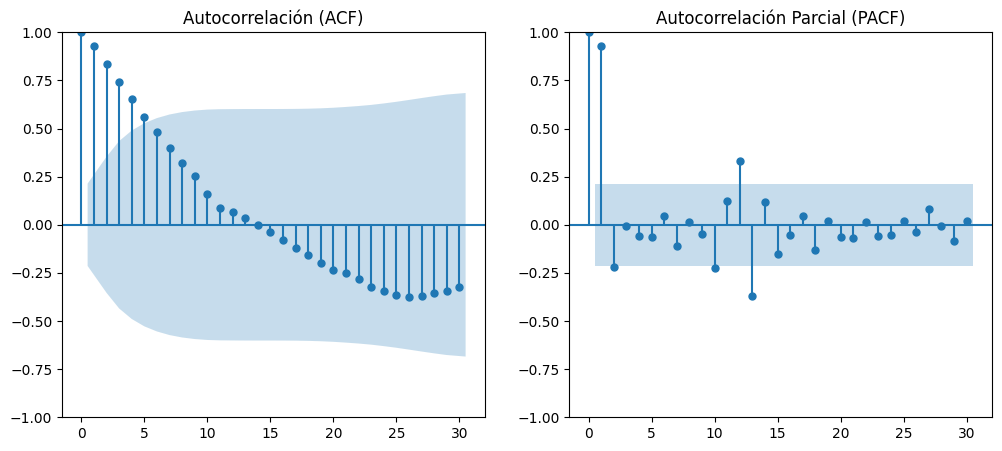

In [56]:
#Gráficos de ACF y PACF para perificar estacionariedad
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(df_linea1["laborables"], lags=30, ax=axes[0])
axes[0].set_title("Autocorrelación (ACF)")
plot_pacf(df_linea1["laborables"], lags=30, ax=axes[1])
axes[1].set_title("Autocorrelación Parcial (PACF)")
plt.show()

# **Tratamiento y Verificaciones antes de Aplicar Modelos**

**Tratamiento de interpolacion para suavizar variabilidad en los anios 2020 y 2021 Pandemia**

Decidi interpolar desde marzo de 2020 hasta diciembre de 2021 ya que fue el periodo extraordinario de la pandemia. El comportamiento durante este rango no reflejan la normalidad de lo que deberia ser la demanda del metro. La pandemia fue un evento único y atípico que alteró el comportamiento de los usuarios y el uso de medio.

In [57]:
#Verifico el índice para asegurar que la serie está bien estructurada
df_linea1 = df_linea1.sort_index()

#verifico la frecuencia mensual
df_linea1.index.freq = "MS"
print(df_linea1.info())

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, 0 to 83
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   mes             84 non-null     datetime64[ns]
 1   laborables      84 non-null     int64         
 2   sabados         84 non-null     int64         
 3   feriados        84 non-null     int64         
 4   año             84 non-null     int64         
 5   dummy_pandemia  84 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 4.6 KB
None


In [58]:
#Copio a partir del df original
df_interpol = df_linea1.copy()

In [59]:
#incluyo variables necesarias
df_interpol = df_linea1[["mes", "laborables", "año"]].copy()

In [60]:
print(df_interpol["año"].astype)

<bound method NDFrame.astype of 0     2018
1     2018
2     2018
3     2018
4     2018
      ... 
79    2024
80    2024
81    2024
82    2024
83    2024
Name: año, Length: 84, dtype: int64>


In [61]:
#asigno como indice la variable mes
df_interpol.set_index('mes', inplace=True)

In [62]:
#convierto TODO el 2020 (excepto enero y febrero) y 2021 en NaN para interpolar
condicion_interpolar = (
    ((df_interpol.index.year == 2020) & (df_interpol.index.month >= 3)) |
     (df_interpol.index.year == 2021)
)

#convierto a NAN antes de interpolar
df_interpol.loc[condicion_interpolar, :] = np.nan

#Aplico interpolación estrategica cúbica solo en la pandemia, el resto del dataser no cambia
df_interpol = df_interpol.interpolate(method='cubic')

In [63]:
#verifico que no queden valores NaN
print("Valores NaN después de interpolación:")
print(df_interpol.isnull().sum())

Valores NaN después de interpolación:
laborables    0
año           0
dtype: int64


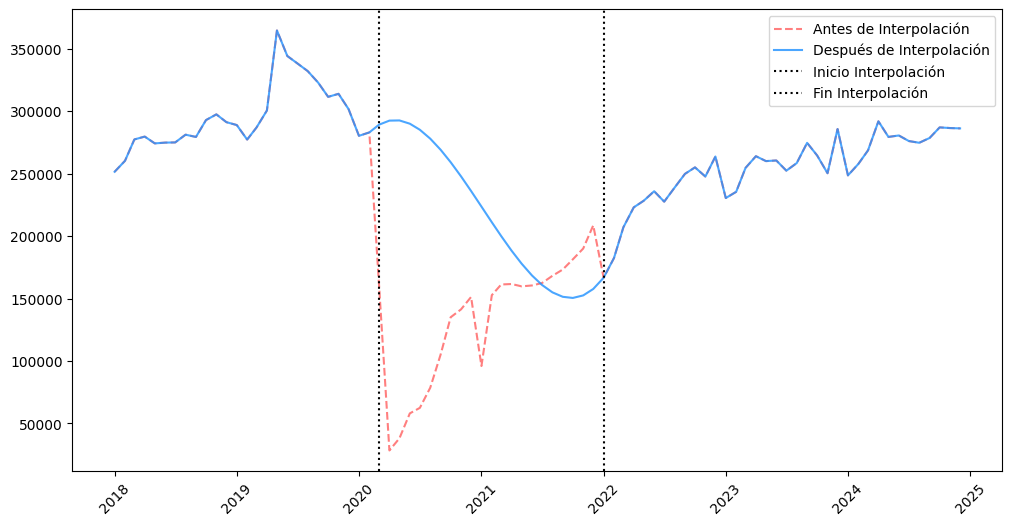

In [64]:
#visualizacion antes y despues de interpolacion estrategica cubica
plt.figure(figsize=(12,6))
plt.plot(df_linea1['mes'], df_linea1["laborables"], label="Antes de Interpolación", linestyle="--", color="red", alpha=0.5)
plt.plot(df_interpol.index, df_interpol["laborables"], label="Después de Interpolación", linestyle="-", color="dodgerblue", alpha=0.8)
plt.axvline(pd.Timestamp("2020-03-01"), color="black", linestyle="dotted", label="Inicio Interpolación")
plt.axvline(pd.Timestamp("2022-01-01"), color="black", linestyle="dotted", label="Fin Interpolación")
plt.legend()
plt.xticks(rotation=45)
plt.show()


# **Modelo ARIMA**

In [65]:
#Divido en conjunto de entrnamiento y prueba por porcentaje total de filas
train_size = int(len(df_interpol) * 0.8)
train, test = df_interpol["laborables"][:train_size], df_interpol["laborables"][train_size:]

print("Tamaño Train:", train.shape)
print("Tamaño Test:", test.shape)


Tamaño Train: (67,)
Tamaño Test: (17,)


**Aplicacion de Grid Search para conseguir los mejores parametros**

In [66]:
#defino el rango de parametros
p = range(0, 3)
d = range(0, 2)
q = range(0, 3)

pdq = list(itertools.product(p, d, q))

best_rmse = float("inf")
best_order = None

for param in pdq:
    try:
        model_arima = ARIMA(train, order=param)
        results_arima = model_arima.fit()
        pred_arima = results_arima.forecast(steps=len(test))
        rmse = np.sqrt(mean_squared_error(test, pred_arima))
        if rmse < best_rmse:
            best_rmse = rmse
            best_order = param
        print(f"ARIMA{param} RMSE: {rmse:.2f}")
    except:
        continue

print(f"\nMejor modelo ARIMA{best_order} con RMSE: {best_rmse:.2f}")


ARIMA(0, 0, 0) RMSE: 23642.35
ARIMA(0, 0, 1) RMSE: 23911.17
ARIMA(0, 0, 2) RMSE: 24063.30
ARIMA(0, 1, 0) RMSE: 24806.82
ARIMA(0, 1, 1) RMSE: 25165.55
ARIMA(0, 1, 2) RMSE: 25652.99
ARIMA(1, 0, 0) RMSE: 24362.76
ARIMA(1, 0, 1) RMSE: 24937.55
ARIMA(1, 0, 2) RMSE: 25155.62
ARIMA(1, 1, 0) RMSE: 25244.24
ARIMA(1, 1, 1) RMSE: 25577.33
ARIMA(1, 1, 2) RMSE: 25785.38
ARIMA(2, 0, 0) RMSE: 25248.09
ARIMA(2, 0, 1) RMSE: 12747.29
ARIMA(2, 0, 2) RMSE: 11769.87
ARIMA(2, 1, 0) RMSE: 25769.03
ARIMA(2, 1, 1) RMSE: 25780.44
ARIMA(2, 1, 2) RMSE: 24915.25

Mejor modelo ARIMA(2, 0, 2) con RMSE: 11769.87


**Ajustamos modelo ARIMA con los mejores parametros obtenidos**

In [67]:
#ajust el modelo ARIMA(2,0,2) con el conjunto de entrenamiento
model_final = ARIMA(train, order=(2,0,2))
result_final = model_final.fit()

#Realizao predicciones
forecast_arima = result_final.forecast(len(test))

#agrego el calculo rmse y mae
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mae_arima = mean_absolute_error(test, forecast_arima)
print(f'RMSE ARIMA(2,0,2): {rmse_arima:.2f}')
print(f'MAE ARIMA(2,0,2): {mae_arima:.2f}')


RMSE ARIMA(2,0,2): 11769.87
MAE ARIMA(2,0,2): 9121.56


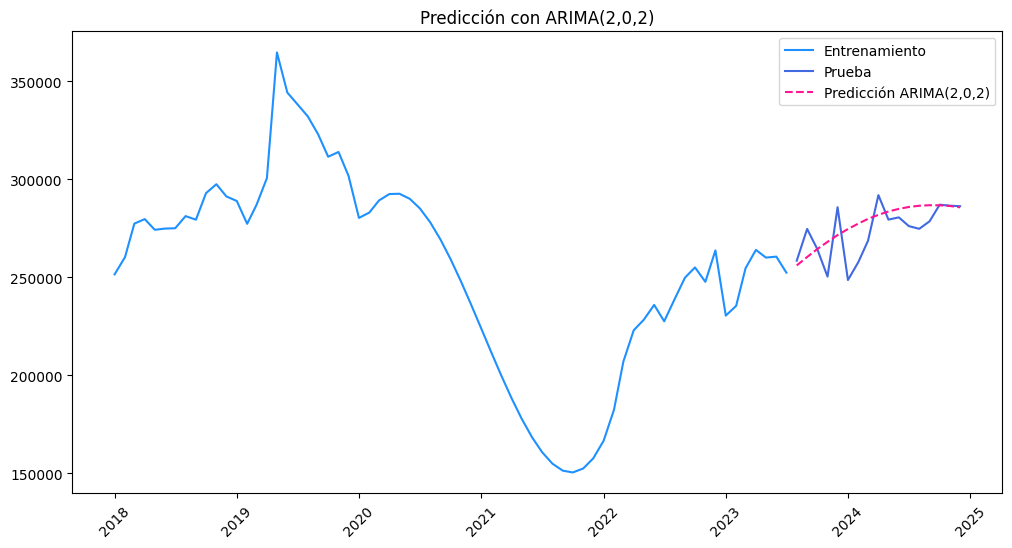

In [68]:
#Creo una grafica comparativa
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Entrenamiento', color='dodgerblue')
plt.plot(test.index, test, label='Prueba', color='royalblue')
plt.plot(test.index, forecast_arima, label='Predicción ARIMA(2,0,2)', color='deeppink', linestyle='--')

plt.title('Predicción con ARIMA(2,0,2)')
plt.legend()
plt.xticks(rotation=45)
plt.show()


In [69]:
#verifico media del conjunto de pruebas
media_test = test.mean()

#calculo en porcentajes medidas de error
rmse_vs_media_test = (rmse_arima / media_test) * 100
mae_vs_media_test = (mae_arima / media_test) * 100

#imprimo resultados
print("Media del conjunto de prueba es de: ", media_test)
print(f"RMSE representa el {rmse_vs_media_test:.2f}% de la media de la demanda en conjunto Prueba")
print(f"MAE representa el {mae_vs_media_test:.2f}% de la media de la demanda en conjunto Prueba")


Media del conjunto de prueba es de:  273614.8823529412
RMSE representa el 4.30% de la media de la demanda en conjunto Prueba
MAE representa el 3.33% de la media de la demanda en conjunto Prueba


# **Modelo SARIMA 1**

In [70]:
print(df_linea1.info)

<bound method DataFrame.info of           mes  laborables  sabados  feriados   año  dummy_pandemia
0  2018-01-01      251595   194234     82150  2018               0
1  2018-02-01      260374   169070     83443  2018               0
2  2018-03-01      277487   222283     91326  2018               0
3  2018-04-01      279776   217594     95591  2018               0
4  2018-05-01      274325   197867     92049  2018               0
..        ...         ...      ...       ...   ...             ...
79 2024-08-01      274821   201032     98796  2024               0
80 2024-09-01      278669   203721     96446  2024               0
81 2024-10-01      287138   193088     94907  2024               0
82 2024-11-01      286616   205954    100663  2024               0
83 2024-12-01      286347   222379    123259  2024               0

[84 rows x 6 columns]>


In [71]:
#Creo un df para el modelo 2
df_model2 = df_linea1.copy()

In [72]:
df_model2["mes"] = pd.to_datetime(df_model2["mes"])
df_model2 = df_model2.set_index("mes")

In [73]:
#Defino el periodo de la pandemia para aplicar la interpolacion lineal para este modelo
condicion_pandemia = (
    ((df_model2.index.year == 2020) & (df_model2.index.month >= 3)) |
    (df_model2.index.year == 2021)
)

#Reemplazo este periodo con nulos
df_model2.loc[condicion_pandemia, "laborables"] = np.nan

#aplico la interpolación lineal SOLO en el periodo de la pandemia
df_model2["laborables"] = df_model2["laborables"].interpolate(method="linear")

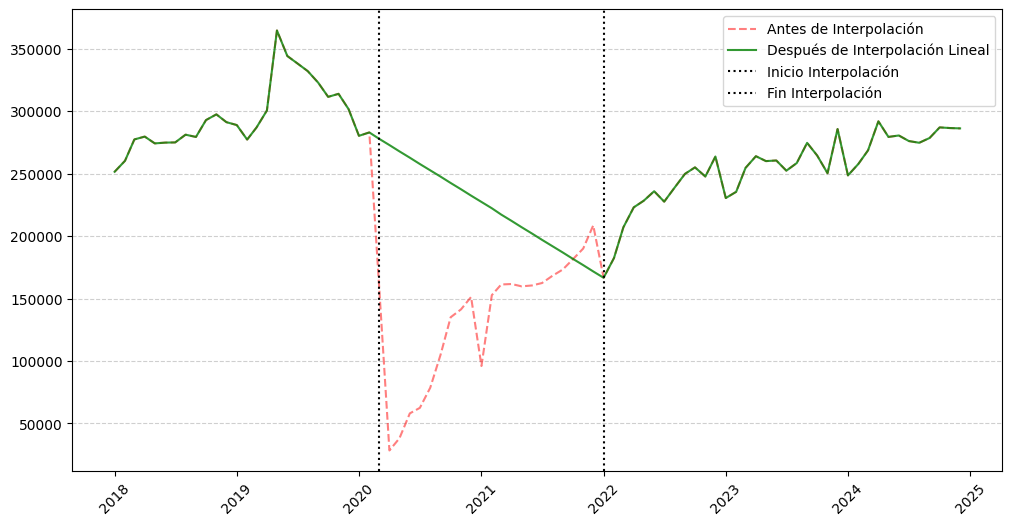

In [74]:
# Visualización antes y después de la interpolación lineal (SARIMA 1)
plt.figure(figsize=(12,6))

# Antes de la interpolación (serie original con valores NaN en pandemia)
plt.plot(df_linea1['mes'], df_linea1["laborables"],
         label="Antes de Interpolación", linestyle="--", color="red", alpha=0.5)

# Después de la interpolación lineal (serie corregida en df_model2)
plt.plot(df_model2.index, df_model2["laborables"],
         label="Después de Interpolación Lineal", linestyle="-", color="green", alpha=0.8)

# Líneas verticales para marcar inicio y fin del periodo de pandemia
plt.axvline(pd.Timestamp("2020-03-01"), color="black", linestyle="dotted", label="Inicio Interpolación")
plt.axvline(pd.Timestamp("2022-01-01"), color="black", linestyle="dotted", label="Fin Interpolación")

# Estética de la gráfica
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


In [75]:
#Divido conjuntos de datos de entrenamiento y prueba excluyendo los años de la pandemia
train_2 = df_model2[df_model2.index.year <= 2022]["laborables"]
test_2 = df_model2[df_model2.index.year >= 2023]["laborables"]

#Verifico el tamaño de los conjuntos
train_2.shape, test_2.shape

((60,), (24,))

In [76]:
#Resultados grid search de pruebas preliminares
best_order_sarima = (1,1,2)
best_seasonal_order_sarima = (0,1,2,12)

In [77]:
#Ajusto el modelo SARIMA con los parámetros (1,1,2)(0,1,2,12)
sarima_model_2 = sm.tsa.SARIMAX(
    train_2,
    order=best_order_sarima,
    seasonal_order=best_seasonal_order_sarima,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

#realizo predicciones sobre el conjunto de prueba
forecast_2 = sarima_model_2.forecast(steps=len(test_2))

#calculo medidas de error sobre la prediccion
rmse_2 = np.sqrt(mean_squared_error(test_2, forecast_2))
mae_2 = mean_absolute_error(test_2, forecast_2)

#imprimo resultados
print("RMSE SARIMA 1: ", rmse_2)
print("MAE SARIMA 1 : ", mae_2)


RMSE SARIMA 1:  447591.0763254676
MAE SARIMA 1 :  381397.25916252023


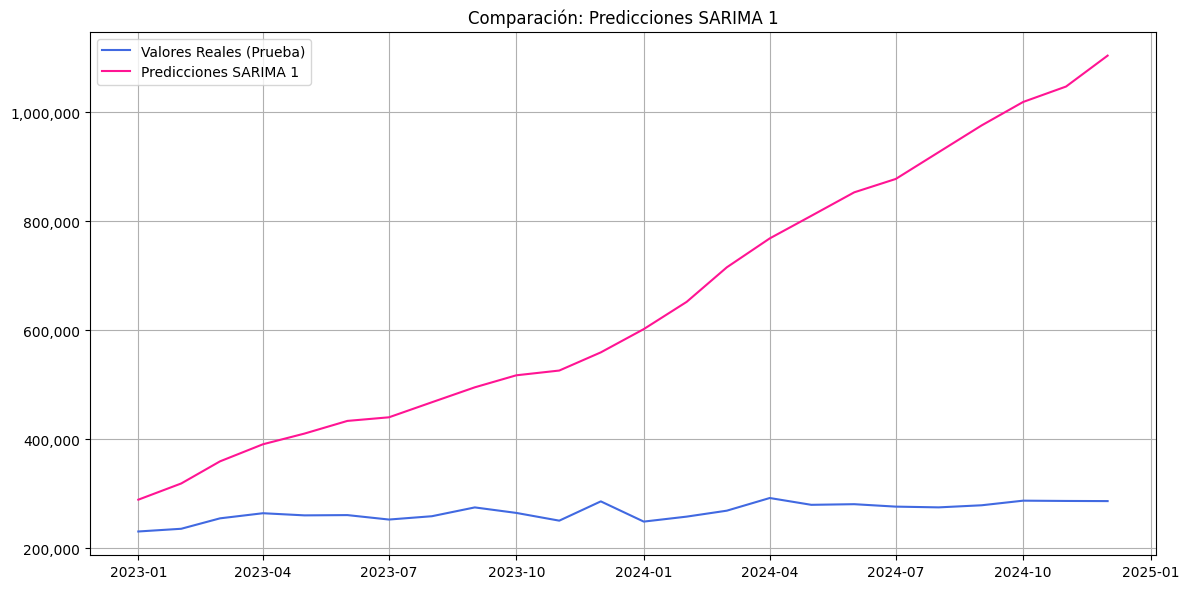

In [78]:
#visualizo los resultados de este modelo versus valores reales
plt.figure(figsize=(12, 6))
plt.plot(test_2.index, test_2.values, label="Valores Reales (Prueba)", color='royalblue')
plt.plot(test_2.index, forecast_2.values, label="Predicciones SARIMA 1", color='deeppink')
plt.title("Comparación: Predicciones SARIMA 1")
plt.legend()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
#calculo media del conjunto de prueba para este modelo
media_test_2 = test_2.mean()

#convierto medidas de error en porcentaje
rmse_2vs_media_test_2 = (rmse_2 / media_test_2) * 100
mae_2vs_media_test_2 = (mae_2 / media_test_2) * 100

#imprimo resultados
print("Media del conjunto de prueba: ", media_test_2)
print(f"RMSE representa el {rmse_2vs_media_test_2:.2f}% de la media de la demanda en conjunto Prueba")
print(f"MAE representa el {mae_2vs_media_test_2:.2f}% de la media de la demanda en conjunto Prueba")

Media del conjunto de prueba:  267063.875
RMSE representa el 167.60% de la media de la demanda en conjunto Prueba
MAE representa el 142.81% de la media de la demanda en conjunto Prueba


# **Modelo SARIMA 2**

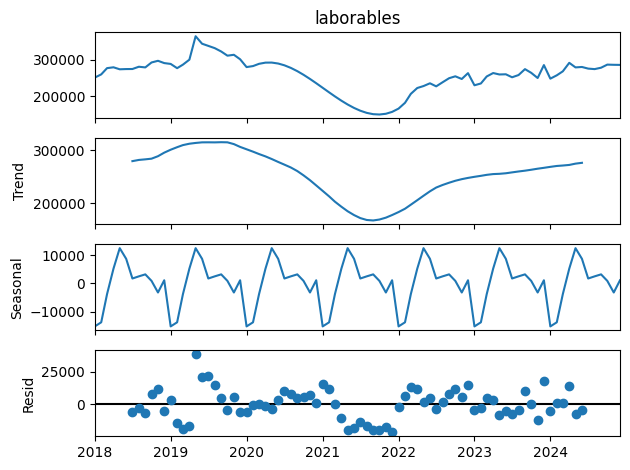

In [80]:
#Me aseguro que la estacionalidad sigue siendo consistente despues de la interpolacion
result_decompose = seasonal_decompose(df_interpol['laborables'], model='additive', period=12)
result_decompose.plot()
plt.show()

In [81]:
#me aseguro que no hayan nulos
print(train.isnull().sum())

0


In [82]:
#ajusto modelo final con los mejores parámetros encontrados uso  el mismo conjunto de entrenamiento que el ARIMA con interpolacion cubica
model_sarima_final = SARIMAX(train, order=best_order_sarima,
                             seasonal_order=best_seasonal_order_sarima,
                             enforce_stationarity=False, enforce_invertibility=False)
result_sarima_final = model_sarima_final.fit()

#realizo predicciones con el mismo conjunto de prueba de ARIMA despues de la interpolacion cubica
forecast_sarima = result_sarima_final.forecast(len(test))

#resultado rmse y mae de SARIMA 1
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
mae_sarima = mean_absolute_error(test, forecast_sarima)
print(f'RMSE SARIMA: {rmse_sarima:.2f}')
print(f'MAE SARIMA: {mae_sarima:.2f}')


RMSE SARIMA: 6252.70
MAE SARIMA: 5031.84


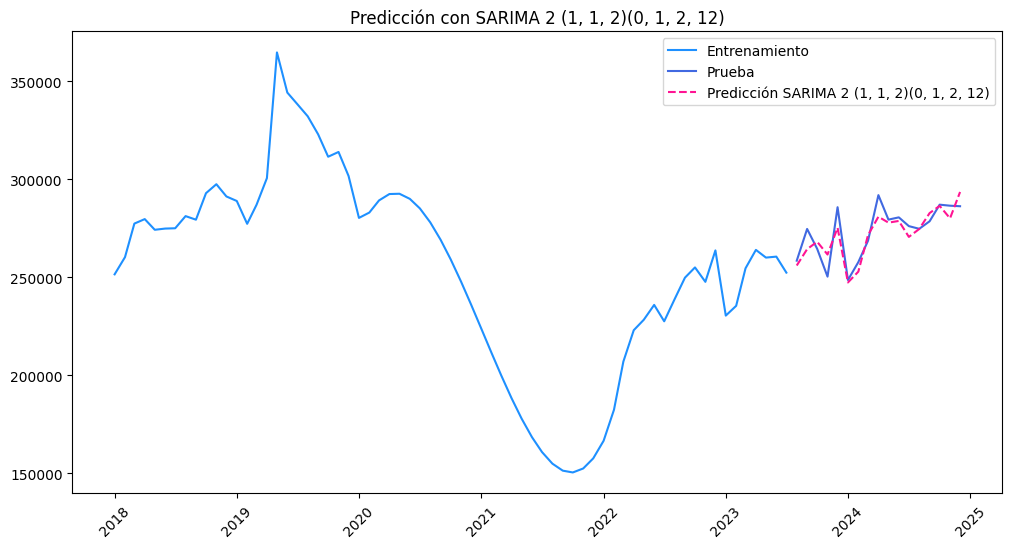

In [83]:
#grafico predicciones
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Entrenamiento', color='dodgerblue')
plt.plot(test.index, test, label='Prueba', color='royalblue')
plt.plot(test.index, forecast_sarima, label=f'Predicción SARIMA 2 {best_order_sarima}{best_seasonal_order_sarima}', color='deeppink', linestyle='--')
plt.title(f'Predicción con SARIMA 2 {best_order_sarima}{best_seasonal_order_sarima}')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [84]:
#confirmo la media del conjunto de pruebas
media_test = test.mean()

#calculo medidas de error en porcentajes
rmse_vs_media_test = (rmse_sarima / media_test) * 100
mae_vs_media_test = (mae_sarima / media_test) * 100

#imprimo resultados
print("Media del conjunto de prueba: ", media_test)
print(f"RMSE representa el {rmse_vs_media_test:.2f}% de la media de la demanda en conjunto Prueba")
print(f"MAE representa el {mae_vs_media_test:.2f}% de la media de la demanda en conjunto Prueba")


Media del conjunto de prueba:  273614.8823529412
RMSE representa el 2.29% de la media de la demanda en conjunto Prueba
MAE representa el 1.84% de la media de la demanda en conjunto Prueba


In [85]:
#Para obtener la predicción con intervalos
pred_sarima = result_sarima_final.get_forecast(steps=11)
pred_mean = pred_sarima.predicted_mean
conf_int = pred_sarima.conf_int()

#Busco intervalos de confianza para los meses especificos entre febrero a mayo de 2024
meses_intervalos = ['2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01']
pred_mean_selected = pred_mean.loc[meses_intervalos]
conf_int_selected = conf_int.loc[meses_intervalos]

#imprimo resultados
print(pred_mean_selected)
print(conf_int_selected)

2024-02-01    252971.222385
2024-03-01    271618.359771
2024-04-01    280989.732765
2024-05-01    277968.303293
Name: predicted_mean, dtype: float64
            lower laborables  upper laborables
2024-02-01      71932.541521     434009.903249
2024-03-01      69547.864861     473688.854681
2024-04-01      59392.839943     502586.625586
2024-05-01      38147.035611     517789.570975


# ***Conclusiones Comparativa Entre Modelos***

In [86]:
#creo tabla comparativa actualizada con los resultados de los 3 modelos
resumen_modelos = pd.DataFrame({
    "Modelo": ["ARIMA", "SARIMA 1", "SARIMA 2" ],
    "RMSE": [10218.03, 447591.07, 6252.7],
    "MAE": [9121.91, 381397.25, 5031.84 ]
})

display(resumen_modelos)

,Modelo,RMSE,MAE
0,ARIMA,10218.03,9121.91
1,SARIMA 1,447591.07,381397.25
2,SARIMA 2,6252.70,5031.84


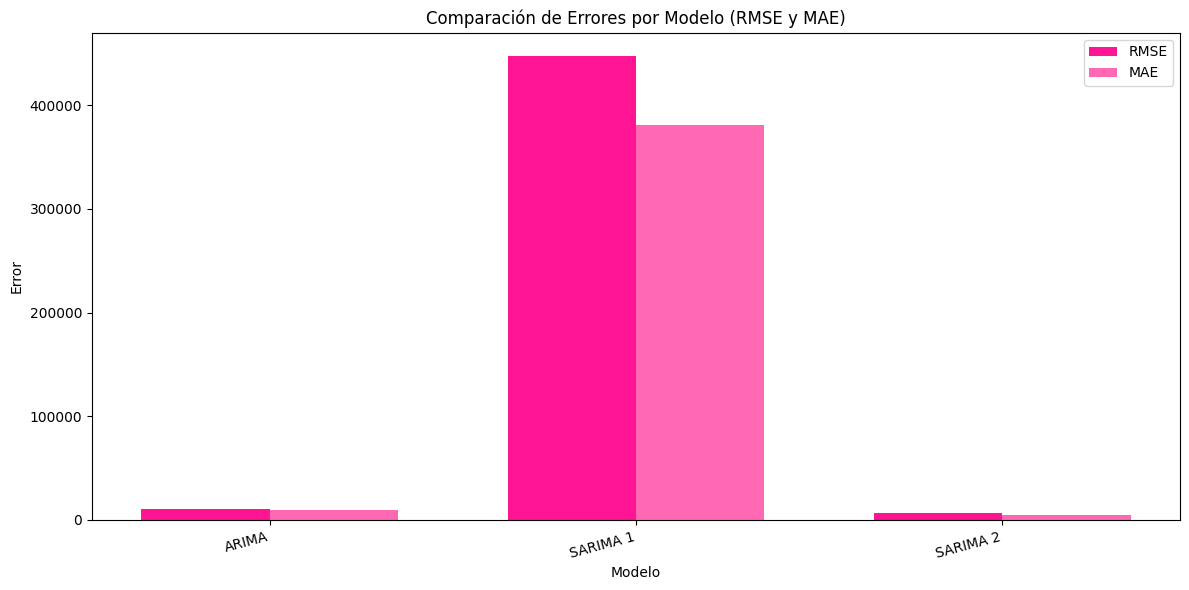

In [87]:
#creo gráfico de barras de la comparativa del resumen de modelos usando las medidas de error como referencia
fig, ax = plt.subplots(figsize=(12,6))
x = range(len(resumen_modelos))
width = 0.35

rmse_bars = ax.bar(x, resumen_modelos["RMSE"], width, label='RMSE', color='deeppink')
mae_bars = ax.bar([i + width for i in x], resumen_modelos["MAE"], width, label='MAE', color='hotpink')

ax.set_xlabel('Modelo')
ax.set_ylabel('Error')
ax.set_title('Comparación de Errores por Modelo (RMSE y MAE)')
ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(resumen_modelos["Modelo"], rotation=15, ha='right')
ax.legend()
plt.tight_layout()

plt.show()


conclusiones en el informe TFM